# 2019-2024 US Stock Market Analysis

นางสาวนภัสสร วัฏฏานนท์ 6621600321

นางสาวอัสวาณี อารง 6621604700

---
## 1. Import Libraries

In [1]:
import numpy as np                                       
import pandas as pd                                    
import matplotlib.pyplot as plt                          
import matplotlib.ticker as mticker
import seaborn as sns                                    
from sklearn.preprocessing import StandardScaler        
from sklearn.cluster import KMeans                     
from sklearn.model_selection import train_test_split      
from sklearn.neighbors import KNeighborsClassifier       
from sklearn.linear_model import LinearRegression         
from sklearn.metrics import (accuracy_score, mean_absolute_error, mean_squared_error, r2_score)
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

---
## 2. Load & Explore Data

In [2]:
stock_market_data = pd.read_csv('Stock Market Dataset.csv')
stock_market_data.head(20)

,Unnamed: 0,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,Platinum_Vol.,Ethereum_Price,Ethereum_Vol.,S&P_500_Price,Nasdaq_100_Price,Nasdaq_100_Vol.,Apple_Price,Apple_Vol.,Tesla_Price,Tesla_Vol.,Microsoft_Price,Microsoft_Vol.,Silver_Price,Silver_Vol.,Google_Price,Google_Vol.,Nvidia_Price,Nvidia_Vol.,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,0,02-02-2024,2.079,NaN,72.28,NaN,3.8215,NaN,"43,194.70",42650.0,901.6,NaN,"2,309.28",246890.0,"4,958.61","17,642.73",315620000.0,185.85,102550000.0,187.91,110610000.0,411.22,28260000.0,22.796,NaN,142.38,62500000.0,661.60,47660000.0,"5,89,498",10580.0,564.64,4030000.0,171.81,117220000.0,474.99,84710000.0,"2,053.70",NaN
1,1,01-02-2024,2.050,161340.0,73.82,577940.0,3.8535,NaN,"43,081.40",47690.0,922.3,NaN,"2,304.28",323610.0,"4,906.19","17,344.71",240640000.0,186.86,53490000.0,188.86,90680000.0,403.78,29230000.0,23.236,85160.0,141.16,37120000.0,630.27,36020000.0,"5,81,600",9780.0,567.51,3150000.0,159.28,66360000.0,394.78,25140000.0,"2,071.10",260920.0
2,2,31-01-2024,2.100,142860.0,75.85,344490.0,3.9060,NaN,"42,580.50",56480.0,932.6,NaN,"2,283.14",408790.0,"4,848.87","17,137.24",366450000.0,184.40,54830000.0,187.29,102270000.0,397.58,46780000.0,23.169,66910.0,140.10,71370000.0,615.27,45070000.0,"5,78,020",9720.0,564.11,4830000.0,155.20,49690000.0,390.14,20010000.0,"2,067.40",238370.0
3,3,30-01-2024,2.077,139750.0,77.82,347240.0,3.9110,NaN,"42,946.20",55130.0,931.7,NaN,"2,343.11",387120.0,"4,924.97","17,476.71",236210000.0,188.04,55270000.0,191.59,105540000.0,408.59,29340000.0,23.225,53370.0,151.46,33060000.0,627.74,39600000.0,"5,84,680",9750.0,562.85,6120000.0,159.00,42290000.0,400.06,18610000.0,"2,050.90",214590.0
4,4,29-01-2024,2.490,3590.0,76.78,331930.0,3.8790,NaN,"43,299.80",45230.0,938.3,NaN,"2,317.79",318840.0,"4,927.93","17,596.27",238750000.0,191.73,46890000.0,190.93,123600000.0,409.72,23290000.0,23.134,330.0,153.51,27590000.0,624.65,33900000.0,"5,78,800",13850.0,575.79,6880000.0,161.26,42840000.0,401.02,17790000.0,"2,034.90",1780.0
5,5,26-01-2024,2.712,73020.0,78.01,365460.0,3.8520,NaN,"41,811.30",69470.0,921.3,NaN,"2,267.55",377790.0,"4,890.97","17,421.01",252940000.0,192.42,44590000.0,183.25,107340000.0,403.93,17800000.0,22.758,330.0,152.18,26120000.0,610.31,39030000.0,"5,82,300",10040.0,570.42,12770000.0,159.12,51050000.0,394.14,13160000.0,"2,026.60",410.0
6,6,25-01-2024,2.571,44980.0,77.36,320180.0,3.8690,NaN,"39,935.70",46300.0,894.5,NaN,"2,217.71",344110.0,"4,894.16","17,516.99",288830000.0,194.17,54530000.0,182.63,198080000.0,404.87,20550000.0,22.814,160.0,151.87,28930000.0,616.17,47310000.0,"5,76,211",9350.0,562.00,9450000.0,157.75,43310000.0,393.18,15090000.0,"2,027.10",460.0
7,7,24-01-2024,2.641,65500.0,75.09,323730.0,3.8860,NaN,"40,086.00",58640.0,914.9,NaN,"2,234.64",373250.0,"4,868.55","17,499.30",259360000.0,194.50,53460000.0,207.83,112940000.0,402.56,23280000.0,22.769,640.0,148.70,25160000.0,613.62,55710000.0,"5,70,977",9560.0,544.87,26350000.0,156.87,47640000.0,390.70,15700000.0,"2,025.40",800.0
8,8,23-01-2024,2.450,69160.0,74.37,306060.0,3.7935,NaN,"39,888.80",82670.0,905.5,NaN,"2,243.74",750520.0,"4,864.60","17,404.21",199930000.0,195.18,42200000.0,209.14,105840000.0,398.90,18230000.0,22.354,210.0,147.04,21190000.0,598.73,29120000.0,"5,64,133",8640.0,492.19,14190000.0,156.02,34930000.0,385.20,15450000.0,"2,035.20",370.0
9,9,22-01-2024,2.419,121580.0,75.19,28910.0,3.7635,NaN,"39,556.40",85100.0,903,NaN,"2,313.64",560840.0,"4,850.43","17,330.38",257760000.0,193.89,60130000.0,208.80,117950000.0,396.51,27020000.0,22.183,910.0,145.99,32200000.0,596.54,45300000.0,"5,58,316",11600.0,485.71,5210000.0,154.78,43690000.0,381.78,17490000.0,"2,031.50",330.0


In [3]:
stock_market_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1243 non-null   int64  
 1   Date               1243 non-null   object 
 2   Natural_Gas_Price  1243 non-null   float64
 3   Natural_Gas_Vol.   1239 non-null   float64
 4   Crude_oil_Price    1243 non-null   float64
 5   Crude_oil_Vol.     1220 non-null   float64
 6   Copper_Price       1243 non-null   float64
 7   Copper_Vol.        1206 non-null   float64
 8   Bitcoin_Price      1243 non-null   object 
 9   Bitcoin_Vol.       1243 non-null   float64
 10  Platinum_Price     1243 non-null   object 
 11  Platinum_Vol.      636 non-null    float64
 12  Ethereum_Price     1243 non-null   object 
 13  Ethereum_Vol.      1243 non-null   float64
 14  S&P_500_Price      1243 non-null   object 
 15  Nasdaq_100_Price   1243 non-null   object 
 16  Nasdaq_100_Vol.    1242 

In [4]:
stock_market_data.columns

Index(['Unnamed: 0', 'Date', 'Natural_Gas_Price', 'Natural_Gas_Vol.',
       'Crude_oil_Price', 'Crude_oil_Vol.', 'Copper_Price', 'Copper_Vol.',
       'Bitcoin_Price', 'Bitcoin_Vol.', 'Platinum_Price', 'Platinum_Vol.',
       'Ethereum_Price', 'Ethereum_Vol.', 'S&P_500_Price', 'Nasdaq_100_Price',
       'Nasdaq_100_Vol.', 'Apple_Price', 'Apple_Vol.', 'Tesla_Price',
       'Tesla_Vol.', 'Microsoft_Price', 'Microsoft_Vol.', 'Silver_Price',
       'Silver_Vol.', 'Google_Price', 'Google_Vol.', 'Nvidia_Price',
       'Nvidia_Vol.', 'Berkshire_Price', 'Berkshire_Vol.', 'Netflix_Price',
       'Netflix_Vol.', 'Amazon_Price', 'Amazon_Vol.', 'Meta_Price',
       'Meta_Vol.', 'Gold_Price', 'Gold_Vol.'],
      dtype='object')

---
## 3. Data Preparation

In [5]:
# Drop the][ 'Unnamed: 0' column
stock_market_data.drop('Unnamed: 0', axis=1, inplace=True)

In [6]:
# Convert 'Date' column to d atetime format
stock_market_data['Date'] = pd.to_datetime(stock_market_data['Date'], format='%d-%m-%Y')  # For "DD-MM-YYYY"

In [7]:
# Find Price columns that are still object type
price_object_columns = [col for col in stock_market_data.columns 
                        if 'Price' in col and stock_market_data[col].dtype == 'object']
# Only convert if there are any columns left
for col in price_object_columns:
    # Remove commas and convert to float
    stock_market_data[col] = stock_market_data[col].str.replace(',', '').astype(float)

In [8]:
stock_market_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               1243 non-null   datetime64[ns]
 1   Natural_Gas_Price  1243 non-null   float64       
 2   Natural_Gas_Vol.   1239 non-null   float64       
 3   Crude_oil_Price    1243 non-null   float64       
 4   Crude_oil_Vol.     1220 non-null   float64       
 5   Copper_Price       1243 non-null   float64       
 6   Copper_Vol.        1206 non-null   float64       
 7   Bitcoin_Price      1243 non-null   float64       
 8   Bitcoin_Vol.       1243 non-null   float64       
 9   Platinum_Price     1243 non-null   float64       
 10  Platinum_Vol.      636 non-null    float64       
 11  Ethereum_Price     1243 non-null   float64       
 12  Ethereum_Vol.      1243 non-null   float64       
 13  S&P_500_Price      1243 non-null   float64       
 14  Nasdaq_1

In [9]:
stock_market_data.isna().sum()

Date                   0
Natural_Gas_Price      0
Natural_Gas_Vol.       4
Crude_oil_Price        0
Crude_oil_Vol.        23
Copper_Price           0
Copper_Vol.           37
Bitcoin_Price          0
Bitcoin_Vol.           0
Platinum_Price         0
Platinum_Vol.        607
Ethereum_Price         0
Ethereum_Vol.          0
S&P_500_Price          0
Nasdaq_100_Price       0
Nasdaq_100_Vol.        1
Apple_Price            0
Apple_Vol.             0
Tesla_Price            0
Tesla_Vol.             0
Microsoft_Price        0
Microsoft_Vol.         0
Silver_Price           0
Silver_Vol.           47
Google_Price           0
Google_Vol.            0
Nvidia_Price           0
Nvidia_Vol.            0
Berkshire_Price        0
Berkshire_Vol.         0
Netflix_Price          0
Netflix_Vol.           0
Amazon_Price           0
Amazon_Vol.            0
Meta_Price             0
Meta_Vol.              0
Gold_Price             0
Gold_Vol.              2
dtype: int64

In [10]:
# Create a column for the day of the week (Monday=0, Sunday=6)
stock_market_data['DayOfWeek'] = stock_market_data['Date'].dt.dayofweek

# Identify price and volume columns
price_columns = [col for col in stock_market_data.columns if 'Price' in col]
volume_columns = [col for col in stock_market_data.columns if 'Vol' in col]

# ---------------------------
# Fill missing values for Price columns
# ---------------------------
for col in price_columns:
    # Linear interpolation to fill missing values
    stock_market_data[col] = stock_market_data[col].interpolate(method='linear')
    
    # Adjust for weekends: use previous day's price if missing
    for i in range(len(stock_market_data)):
        if pd.isnull(stock_market_data.loc[i, col]):
            if stock_market_data.loc[i, 'DayOfWeek'] in [5, 6]:  # Saturday or Sunday
                if i > 0 and pd.notnull(stock_market_data.loc[i-1, col]):
                    stock_market_data.loc[i, col] = stock_market_data.loc[i-1, col]

# ---------------------------
# Fill missing values for Volume columns
# ---------------------------
for col in volume_columns:
    for i in range(len(stock_market_data)):
        if pd.isnull(stock_market_data.loc[i, col]):
            if stock_market_data.loc[i, 'DayOfWeek'] in [5, 6]:  # Saturday or Sunday
                stock_market_data.loc[i, col] = 0
            else:
                # Use mean of previous and next day's volume if available
                prev_val = next_val = None
                if i > 0:
                    prev_val = stock_market_data.loc[i-1, col]
                if i < len(stock_market_data) - 1:
                    next_val = stock_market_data.loc[i+1, col]
                if pd.notnull(prev_val) and pd.notnull(next_val):
                    stock_market_data.loc[i, col] = (prev_val + next_val) / 2
                elif pd.notnull(prev_val):
                    stock_market_data.loc[i, col] = prev_val
                elif pd.notnull(next_val):
                    stock_market_data.loc[i, col] = next_val

# Drop 'DayOfWeek' column if no longer needed
stock_market_data.drop('DayOfWeek', axis=1, inplace=True)

In [11]:
stock_market_data.isna().sum()

Date                  0
Natural_Gas_Price     0
Natural_Gas_Vol.      0
Crude_oil_Price       0
Crude_oil_Vol.        0
Copper_Price          0
Copper_Vol.          25
Bitcoin_Price         0
Bitcoin_Vol.          0
Platinum_Price        0
Platinum_Vol.        22
Ethereum_Price        0
Ethereum_Vol.         0
S&P_500_Price         0
Nasdaq_100_Price      0
Nasdaq_100_Vol.       0
Apple_Price           0
Apple_Vol.            0
Tesla_Price           0
Tesla_Vol.            0
Microsoft_Price       0
Microsoft_Vol.        0
Silver_Price          0
Silver_Vol.           0
Google_Price          0
Google_Vol.           0
Nvidia_Price          0
Nvidia_Vol.           0
Berkshire_Price       0
Berkshire_Vol.        0
Netflix_Price         0
Netflix_Vol.          0
Amazon_Price          0
Amazon_Vol.           0
Meta_Price            0
Meta_Vol.             0
Gold_Price            0
Gold_Vol.             0
dtype: int64

In [12]:
# Select rows where Platinum_Vol. or Copper_Vol. is NaN
nan_rows = stock_market_data[stock_market_data['Platinum_Vol.'].isna() | 
                             stock_market_data['Copper_Vol.'].isna()]

# Display only specific columns as a table
nan_rows[['Date', 'Copper_Price', 'Copper_Vol.', 'Platinum_Price', 'Platinum_Vol.']]

,Date,Copper_Price,Copper_Vol.,Platinum_Price,Platinum_Vol.
0,2024-02-02,3.8215,NaN,901.6,NaN
1,2024-02-01,3.8535,NaN,922.3,NaN
2,2024-01-31,3.9060,NaN,932.6,NaN
3,2024-01-30,3.9110,NaN,931.7,NaN
4,2024-01-29,3.8790,NaN,938.3,NaN
5,2024-01-26,3.8520,NaN,921.3,NaN
6,2024-01-25,3.8690,NaN,894.5,NaN
7,2024-01-24,3.8860,NaN,914.9,NaN
8,2024-01-23,3.7935,NaN,905.5,NaN
9,2024-01-22,3.7635,NaN,903.0,NaN


In [13]:
# Remove rows where Platinum_Vol. OR Copper_Vol. is NaN
stock_market_data = stock_market_data.dropna(
    subset=['Platinum_Vol.', 'Copper_Vol.']
)

# Reset index (optional but recommended)
stock_market_data = stock_market_data.reset_index(drop=True)

In [14]:
stock_market_data.isna().sum()

Date                 0
Natural_Gas_Price    0
Natural_Gas_Vol.     0
Crude_oil_Price      0
Crude_oil_Vol.       0
Copper_Price         0
Copper_Vol.          0
Bitcoin_Price        0
Bitcoin_Vol.         0
Platinum_Price       0
Platinum_Vol.        0
Ethereum_Price       0
Ethereum_Vol.        0
S&P_500_Price        0
Nasdaq_100_Price     0
Nasdaq_100_Vol.      0
Apple_Price          0
Apple_Vol.           0
Tesla_Price          0
Tesla_Vol.           0
Microsoft_Price      0
Microsoft_Vol.       0
Silver_Price         0
Silver_Vol.          0
Google_Price         0
Google_Vol.          0
Nvidia_Price         0
Nvidia_Vol.          0
Berkshire_Price      0
Berkshire_Vol.       0
Netflix_Price        0
Netflix_Vol.         0
Amazon_Price         0
Amazon_Vol.          0
Meta_Price           0
Meta_Vol.            0
Gold_Price           0
Gold_Vol.            0
dtype: int64

In [15]:
stock_market_data.head(10)

,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,Platinum_Vol.,Ethereum_Price,Ethereum_Vol.,S&P_500_Price,Nasdaq_100_Price,Nasdaq_100_Vol.,Apple_Price,Apple_Vol.,Tesla_Price,Tesla_Vol.,Microsoft_Price,Microsoft_Vol.,Silver_Price,Silver_Vol.,Google_Price,Google_Vol.,Nvidia_Price,Nvidia_Vol.,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,2023-12-27,2.619,3930.0,74.11,253320.0,3.9560,38000.0,43446.5,50100.0,1013.5,18530.0,2378.63,577270.0,4781.58,16906.80,182990000.0,193.15,47900000.0,261.44,105860000.0,374.07,14870000.0,24.570,13945.0,140.37,19570000.0,494.17,23220000.0,543750.0,7620.0,491.79,2550000.0,153.34,31240000.0,357.83,13210000.0,2083.4,590.0
1,2023-12-26,2.550,50760.0,75.57,208720.0,3.9020,38000.0,42513.3,56030.0,995.6,18530.0,2230.74,429500.0,4774.75,16878.46,146740000.0,193.05,28810000.0,256.61,86640000.0,374.66,12650000.0,24.396,27810.0,141.52,16530000.0,492.79,24280000.0,543635.0,10890.0,491.19,2030000.0,153.41,24870000.0,354.83,9880000.0,2060.4,290.0
2,2023-12-22,2.610,42840.0,73.56,222600.0,3.9050,54140.0,43968.9,44500.0,981.8,22540.0,2324.23,620730.0,4754.63,16777.40,170680000.0,193.60,37150000.0,252.54,93370000.0,374.58,17110000.0,24.565,48680.0,141.49,26530000.0,488.30,25250000.0,542600.0,7840.0,486.76,2700000.0,153.42,29510000.0,353.39,11770000.0,2059.6,440.0
3,2023-12-21,2.572,84550.0,73.89,251980.0,3.9175,70080.0,43865.9,48960.0,970.3,26550.0,2239.62,471460.0,4746.75,16757.41,217170000.0,194.68,44080000.0,254.50,108960000.0,373.54,17630000.0,24.585,46760.0,140.42,27400000.0,489.90,29920000.0,541000.0,7700.0,491.61,2750000.0,153.84,35950000.0,354.09,15220000.0,2041.8,540.0
4,2023-12-20,2.447,125260.0,74.22,273360.0,3.9060,66320.0,43662.8,70190.0,974.0,30010.0,2202.19,440350.0,4701.19,16554.16,275300000.0,194.83,50130000.0,247.14,124130000.0,370.62,26020000.0,24.631,46980.0,138.34,48940000.0,481.11,39400000.0,543740.0,8150.0,489.27,4520000.0,152.12,50000000.0,349.28,15990000.0,2038.1,260.0
5,2023-12-19,2.492,170440.0,73.44,25690.0,3.8980,84950.0,42259.3,55290.0,965.8,25860.0,2177.44,400940.0,4768.37,16811.86,228940000.0,196.94,40230000.0,257.22,106290000.0,373.26,20530000.0,24.321,37540.0,136.65,25440000.0,496.04,46310000.0,554650.0,7500.0,495.02,3840000.0,153.79,42890000.0,350.36,17660000.0,2042.6,470.0
6,2023-12-18,2.503,154300.0,72.47,73940.0,3.8520,54990.0,42659.7,61580.0,954.3,26230.0,2218.80,388260.0,4740.56,16729.80,249620000.0,195.89,55750000.0,252.08,116420000.0,372.65,21800000.0,24.107,42680.0,135.80,32260000.0,500.77,41260000.0,551182.0,10460.0,486.12,6410000.0,154.07,62510000.0,344.62,18360000.0,2030.9,250.0
7,2023-12-15,2.491,189240.0,71.43,95510.0,3.8905,73670.0,41929.0,45280.0,952.6,38070.0,2220.41,349630.0,4719.19,16623.45,982560000.0,197.57,128540000.0,253.50,135930000.0,370.73,78500000.0,24.154,57000.0,132.60,50850000.0,488.90,47990000.0,544478.0,8430.0,472.06,7840000.0,149.97,110090000.0,334.92,31780000.0,2026.0,630.0
8,2023-12-14,2.392,159490.0,71.58,275690.0,3.8925,107540.0,43025.9,59150.0,967.9,42830.0,2315.64,461600.0,4719.55,16537.83,392380000.0,198.11,65960000.0,251.05,160120000.0,365.93,43070000.0,24.386,97580.0,131.94,38600000.0,483.50,38160000.0,549760.0,8110.0,469.83,5070000.0,147.42,57940000.0,333.17,19340000.0,2035.2,560.0
9,2023-12-13,2.335,255190.0,69.47,307000.0,3.7875,62860.0,42884.5,63110.0,922.1,32250.0,2260.18,436640.0,4707.09,16562.37,265120000.0,197.96,67760000.0,239.29,145290000.0,374.37,30360000.0,22.921,81890.0,132.57,29640000.0,480.88,43610000.0,555800.0,7810.0,479.98,5750000.0,148.84,51650000.0,334.74,16200000.0,1988.1,2220.0


In [16]:
# เรียงข้อมูลจากเก่า → ใหม่ ก่อนคำนวณ Time Series ทุกครั้ง
stock_market_data = stock_market_data.sort_values('Date').reset_index(drop=True)
print(f"Date range: {stock_market_data['Date'].min().date()} → {stock_market_data['Date'].max().date()}")
print(f"Shape: {stock_market_data.shape} | Total missing: {stock_market_data.isnull().sum().sum()}")

Date range: 2019-02-04 → 2023-12-27
Shape: (1218, 38) | Total missing: 0


---
## คำถามที่ 1 — ปริมาณการซื้อขาย (Volume) ส่งผลต่อการทำนายราคาหุ้นหรือไม่?


**เป้าหมาย:** ศึกษาว่า **ปริมาณการซื้อขาย (Volume)** สามารถใช้เป็นตัวแปรในการ **ทำนายราคาหุ้น (Price)** ได้หรือไม่ โดยใช้วิธี **Linear Regression** และประเมินประสิทธิภาพของโมเดลด้วยค่า **R² (R-squared)**

- หากค่า **R² สูง** แสดงว่า Volume สามารถอธิบายการเปลี่ยนแปลงของราคาหุ้นได้ดี  
- หากค่า **R² ต่ำ** แสดงว่า Volume ไม่ได้มีอิทธิพลต่อราคาหุ้นมากนัก

ในการวิเคราะห์ครั้งนี้เลือกใช้ **Tesla** มีความเป็นไปได้ที่จะพบความสัมพันธ์ระหว่าง **Volume และ Price movement**

In [17]:
# -----------------------------
# เตรียมข้อมูล Tesla หลังจาก clean แล้ว
# -----------------------------
tesla = stock_market_data[['Date','Tesla_Price','Tesla_Vol.']].dropna()

# สร้าง feature ราคาย้อนหลัง 1 วัน
tesla['Price_lag1'] = tesla['Tesla_Price'].shift(1)
tesla = tesla.dropna()  # ลบแถวแรกที่เป็น NaN จาก lag

# ตัวแปรเป้าหมาย
y = tesla['Tesla_Price']

### Model 1: Price → Predict Price

In [18]:
# -----------------------------
# Model A: Price_lag1 Only
# -----------------------------
X_A = tesla[['Price_lag1']]
ct_A = ColumnTransformer(transformers=[('pass', 'passthrough', ['Price_lag1'])])
X_A_transformed = ct_A.fit_transform(X_A)

X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A_transformed, y, test_size=0.2, random_state=42
)
model_A = LinearRegression()
model_A.fit(X_A_train, y_A_train)
y_A_pred = model_A.predict(X_A_test)
r2_A = r2_score(y_A_test, y_A_pred)
mae_A = mean_absolute_error(y_A_test, y_A_pred)
print("=== Model A: Price_lag1 Only ===")
print("R²:", r2_A)
print("MAE:", mae_A)

=== Model A: Price_lag1 Only ===
R²: 0.994123635067792
MAE: 5.075376869764093


### Model 2: Volume → Predict Price

In [19]:
# -----------------------------
# Model B: Volume Only
# -----------------------------
X_B = tesla[['Tesla_Vol.']]
ct_B = ColumnTransformer(transformers=[('pass', 'passthrough', ['Tesla_Vol.'])])
X_B_transformed = ct_B.fit_transform(X_B)

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B_transformed, y, test_size=0.2, random_state=42
)
model_B = LinearRegression()
model_B.fit(X_B_train, y_B_train)
y_B_pred = model_B.predict(X_B_test)
r2_B = r2_score(y_B_test, y_B_pred)
mae_B = mean_absolute_error(y_B_test, y_B_pred)
print("\n=== Model B: Volume Only ===")
print("R²:", r2_B)
print("MAE:", mae_B)


=== Model B: Volume Only ===
R²: 0.20103069006413066
MAE: 76.4860693081988


### Model 3: Price_lag1 + Volume → Predict Price

In [20]:
# -----------------------------
# Model C: Price_lag1 + Volume
# -----------------------------
X_C = tesla[['Price_lag1', 'Tesla_Vol.']]
ct_C = ColumnTransformer(transformers=[('pass', 'passthrough', ['Price_lag1', 'Tesla_Vol.'])])
X_C_transformed = ct_C.fit_transform(X_C)

X_C_train, X_C_test, y_C_train, y_C_test = train_test_split(
    X_C_transformed, y, test_size=0.2, random_state=42
)
model_C = LinearRegression()
model_C.fit(X_C_train, y_C_train)
y_C_pred = model_C.predict(X_C_test)
r2_C = r2_score(y_C_test, y_C_pred)
mae_C = mean_absolute_error(y_C_test, y_C_pred)
print("\n=== Model C: Price_lag1 + Volume ===")
print("R²:", r2_C)
print("MAE:", mae_C)


=== Model C: Price_lag1 + Volume ===
R²: 0.9941441138994461
MAE: 5.025945551295135


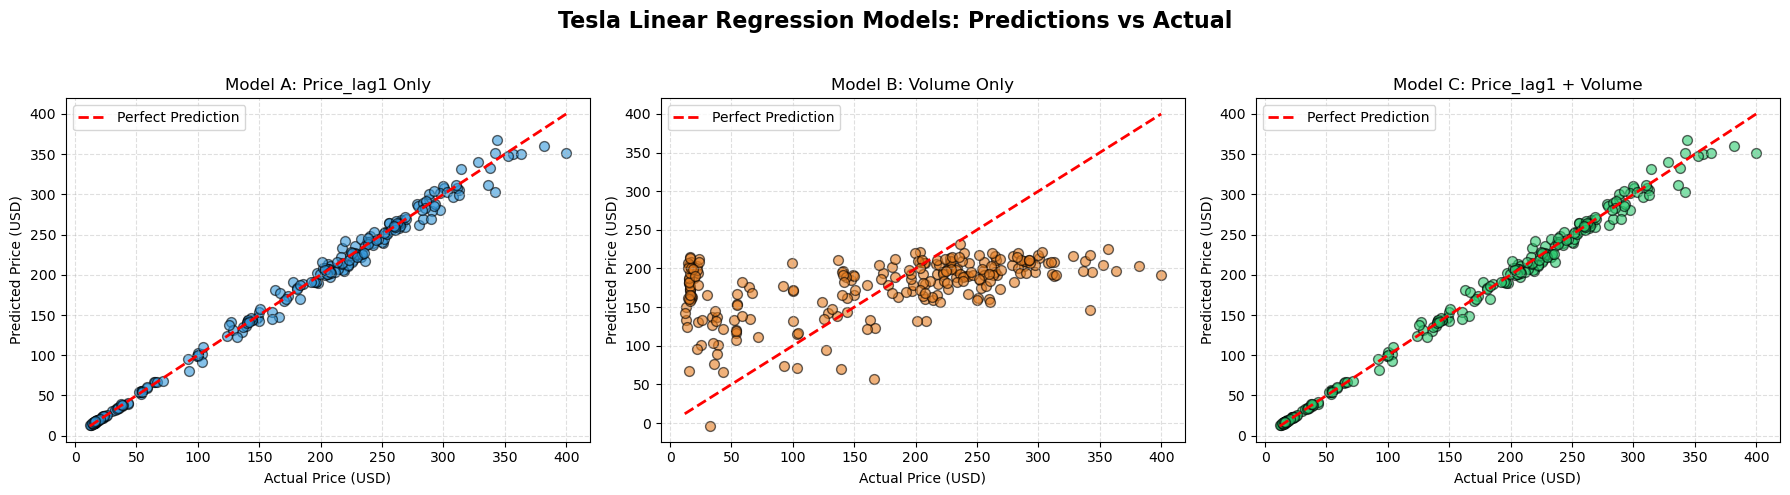

In [21]:
# -----------------------------
# Figure 1: Scatter Plots (1 row x 3 columns)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Tesla Linear Regression Models: Predictions vs Actual', fontsize=16, fontweight='bold')

# Model A
axes[0].scatter(y_A_test, y_A_pred, color='#3498db', alpha=0.6, edgecolor='k', s=50)
axes[0].plot([y_A_test.min(), y_A_test.max()],
             [y_A_test.min(), y_A_test.max()],
             color='red', linestyle='--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title('Model A: Price_lag1 Only')
axes[0].legend()
axes[0].grid(axis='both', linestyle='--', alpha=0.4)

# Model B
axes[1].scatter(y_B_test, y_B_pred, color='#e67e22', alpha=0.6, edgecolor='k', s=50)
axes[1].plot([y_B_test.min(), y_B_test.max()],
             [y_B_test.min(), y_B_test.max()],
             color='red', linestyle='--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')
axes[1].set_title('Model B: Volume Only')
axes[1].legend()
axes[1].grid(axis='both', linestyle='--', alpha=0.4)

# Model C
axes[2].scatter(y_C_test, y_C_pred, color='#2ecc71', alpha=0.6, edgecolor='k', s=50)
axes[2].plot([y_C_test.min(), y_C_test.max()],
             [y_C_test.min(), y_C_test.max()],
             color='red', linestyle='--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Price (USD)')
axes[2].set_ylabel('Predicted Price (USD)')
axes[2].set_title('Model C: Price_lag1 + Volume')
axes[2].legend()
axes[2].grid(axis='both', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

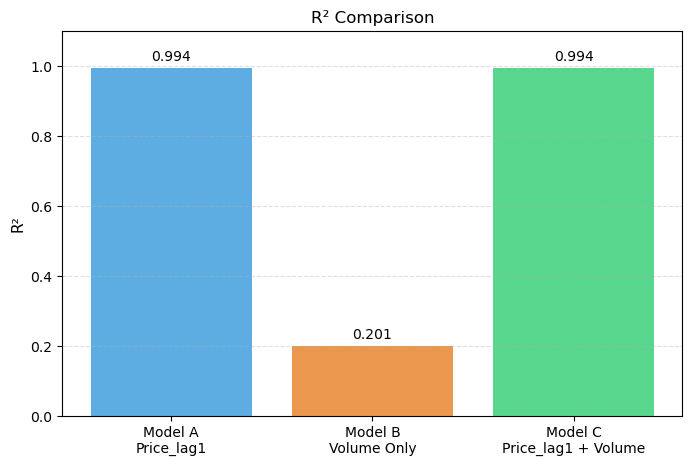

In [22]:
# -----------------------------
# Figure 2: Bar Chart Comparison (R²)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))
models = ['Model A\nPrice_lag1', 'Model B\nVolume Only', 'Model C\nPrice_lag1 + Volume']
r2_scores = [r2_A, r2_B, r2_C]
mae_scores = [mae_A, mae_B, mae_C]

bars = ax.bar(models, r2_scores, color=['#3498db','#e67e22','#2ecc71'], alpha=0.8)
ax.set_ylabel('R²', fontsize=11)
ax.set_ylim(0,1.1)
ax.set_title('R² Comparison')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# เพิ่มค่าตัวเลขบน bar
for bar, val in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontsize=10)

plt.show()

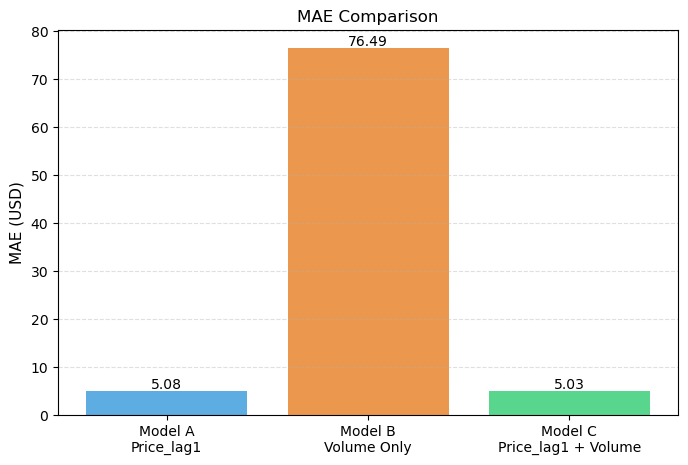

In [23]:
# -----------------------------
# Figure 3: Bar Chart Comparison (MAE)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))
models = ['Model A\nPrice_lag1', 'Model B\nVolume Only', 'Model C\nPrice_lag1 + Volume']

# ใช้ mae_scores ที่คำนวณไว้ก่อนหน้า
bars = ax.bar(models, mae_scores, color=['#3498db','#e67e22','#2ecc71'], alpha=0.8)
ax.set_ylabel('MAE (USD)', fontsize=11)
ax.set_title('MAE Comparison')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# เพิ่มค่าตัวเลขบน bar
for bar, val in zip(bars, mae_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.2f}', ha='center', fontsize=10)

plt.show()

---
## คำถามที่ 2 — เหตุการณ์สำคัญโลก (COVID, Fed Rate, FTX, Tesla Stock Split) ส่งผลต่อ Tesla และ Bitcoin อย่างไร?


**เป้าหมาย:**  วิเคราะห์ผลกระทบของเหตุการณ์สำคัญระดับโลก เช่น COVID-19, Fed Rate Hike, และ FTX Collapse ต่อความผันผวน (Volatility) ของ **Tesla** และ **Bitcoin**

**เหตุการณ์สำคัญที่วิเคราะห์**

| เหตุการณ์ | วันที่ | เหตุผลที่เลือก |
|-----------|--------|----------------|
| COVID-19 Crash | 16-03-2020 | ตลาดหุ้นร่วงหนัก Tesla และ Bitcoin ปรับตัวรุนแรง |
| Tesla Stock Split | 31-08-2020 | ราคาหุ้น Tesla ปรับตัวขึ้นทันทีหลัง split |
| Fed Rate Hike | 15-06-2022 | ตลาดหุ้นและคริปโตปรับตัวลงแรงหลังประกาศ |
| FTX Collapse | 11-11-2022 | Bitcoin ร่วงแรงทันทีหลังข่าวล้มละลาย |

In [24]:
# เตรียมข้อมูลราคาของ Tesla และ Bitcoin
assets = ['Tesla_Price', 'Bitcoin_Price']
prices = stock_market_data[['Date'] + assets].dropna()
prices['Date'] = pd.to_datetime(prices['Date'])
prices.set_index('Date', inplace=True)

In [25]:
# คำนวณ Daily Return (%)
daily_returns = prices.pct_change().dropna() * 100

In [26]:
# กำหนดเหตุการณ์สำคัญ
events = {
    'COVID-19 Crash': pd.to_datetime('2020-03-16'),
    'Tesla Stock Split': pd.to_datetime('2020-08-31'),
    'Fed Rate Hike': pd.to_datetime('2022-06-15'),
    'FTX Collapse': pd.to_datetime('2022-11-11')
}

In [27]:
# จำนวนวันรอบเหตุการณ์
window = 30
rolling_window = 7  # Rolling volatility 7 วัน

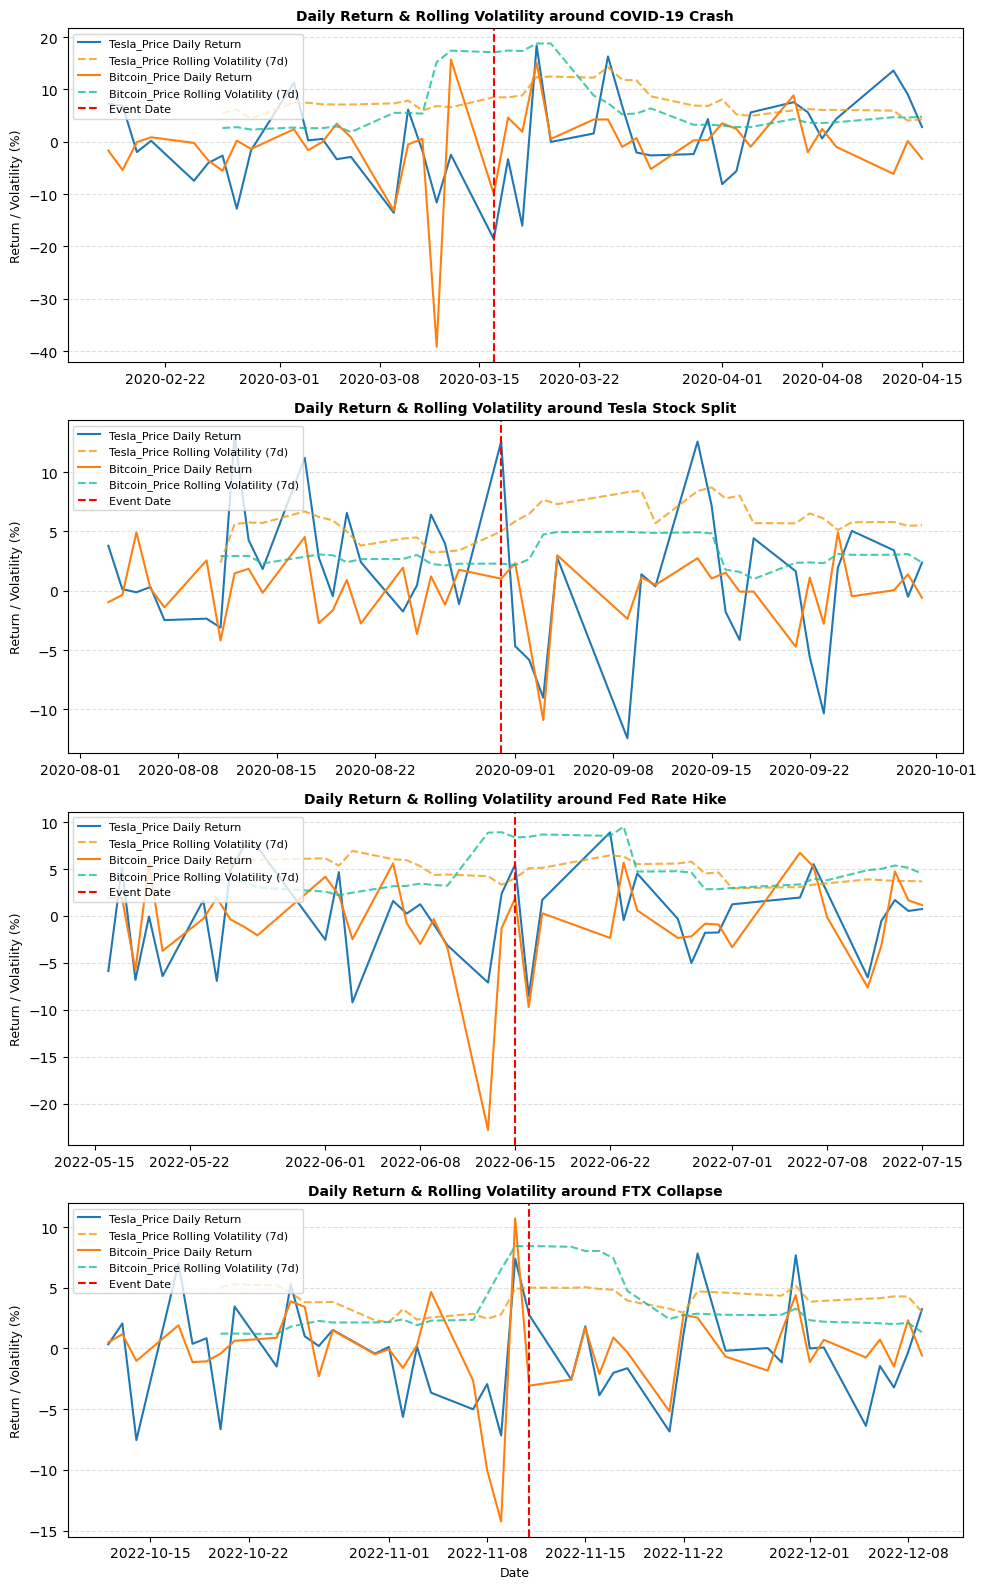

In [28]:
# ปรับ Timeline Plot ขนาดเล็กลง
fig, axes = plt.subplots(len(events), 1, figsize=(10, 4*len(events)), sharey=False)  # ลดความสูงแต่ละ subplot

if len(events) == 1:
    axes = [axes]  # ถ้าเหตุการณ์เดียวให้ convert เป็น list

for ax, (event_name, event_date) in zip(axes, events.items()):
    start = event_date - pd.Timedelta(days=window)
    end = event_date + pd.Timedelta(days=window)
    
    # เลือกข้อมูลรอบเหตุการณ์
    event_returns = daily_returns.loc[start:end]
    
    # Plot Daily Return line
    for asset, color in zip(assets, ['#f39c12', '#1abc9c']):
        ax.plot(event_returns.index, event_returns[asset], label=f'{asset} Daily Return', lw=1.5)  # ลดความหนาเส้น
        rolling_vol = event_returns[asset].rolling(window=rolling_window).std()
        ax.plot(event_returns.index, rolling_vol, label=f'{asset} Rolling Volatility (7d)', linestyle='--', lw=1.5, alpha=0.8, color=color)
    
    # เส้น vertical แสดงวันเหตุการณ์
    ax.axvline(event_date, color='red', linestyle='--', lw=1.5, label='Event Date')
    
    ax.set_title(f'Daily Return & Rolling Volatility around {event_name}', fontsize=10, fontweight='bold')  # ลดขนาด title
    ax.set_ylabel('Return / Volatility (%)', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='upper left', fontsize=8)  # ลดขนาด legend

axes[-1].set_xlabel('Date', fontsize=9)
plt.tight_layout()
plt.show()

---
## คำถามที่ 3  — Linear Regression: พยากรณ์ราคา Bitcoin

**เป้าหมาย:** ใช้ราคา Bitcoin ย้อนหลัง 5 วัน (Lag Features) พยากรณ์ราคาวันถัดไป

In [29]:
btc_prices = stock_market_data['Bitcoin_Price'].dropna().values

print("=== Bitcoin Price ===")
print(f"  np.mean   : ${np.mean(btc_prices):>10,.0f}")
print(f"  np.std    : ${np.std(btc_prices):>10,.0f}")
print(f"  np.min    : ${np.min(btc_prices):>10,.0f}")
print(f"  np.max    : ${np.max(btc_prices):>10,.0f}")
print(f"  np.median : ${np.median(btc_prices):>10,.0f}")

=== Bitcoin Price ===
  np.mean   : $    24,878
  np.std    : $    15,978
  np.min    : $     3,398
  np.max    : $    67,528
  np.median : $    22,654


In [30]:
reg_df = stock_market_data[['Date','Bitcoin_Price']].dropna().copy()

for lag in range(1, 6):
    reg_df[f'BTC_Lag{lag}'] = reg_df['Bitcoin_Price'].shift(lag)

reg_df = reg_df.dropna().reset_index(drop=True)

lag_cols = [f'BTC_Lag{i}' for i in range(1, 6)]
X_lr = reg_df[lag_cols]
y_lr = reg_df['Bitcoin_Price']

# ── StandardScaler + Train/Test Split (80:20) ─────────────────────
scaler_lr = StandardScaler()
split     = int(len(X_lr) * 0.8)

X_train_lr = scaler_lr.fit_transform(X_lr.iloc[:split])
X_test_lr  = scaler_lr.transform(X_lr.iloc[split:])
y_train_lr = y_lr.iloc[:split]
y_test_lr  = y_lr.iloc[split:]

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

y_pred_lr = lr_model.predict(X_test_lr)

mae  = mean_absolute_error(y_test_lr, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
r2   = r2_score(y_test_lr, y_pred_lr)

print("=== Linear Regression — Bitcoin Price Prediction ===")
print(f"  MAE  (Mean Absolute Error) : ${mae:>8,.0f}")
print(f"  RMSE (Root Mean Sq Error)  : ${rmse:>8,.0f}")
print(f"  R²   (Coefficient of Det.) : {r2:.4f}")
print()
print(f"  Coefficients (5 Lags):")
for lag, coef in zip(lag_cols, lr_model.coef_):
    print(f"    {lag}: {coef:+.4f}")

=== Linear Regression — Bitcoin Price Prediction ===
  MAE  (Mean Absolute Error) : $     587
  RMSE (Root Mean Sq Error)  : $     846
  R²   (Coefficient of Det.) : 0.9764

  Coefficients (5 Lags):
    BTC_Lag1: +17347.9617
    BTC_Lag2: +440.5076
    BTC_Lag3: +131.8378
    BTC_Lag4: +37.1727
    BTC_Lag5: -532.4140


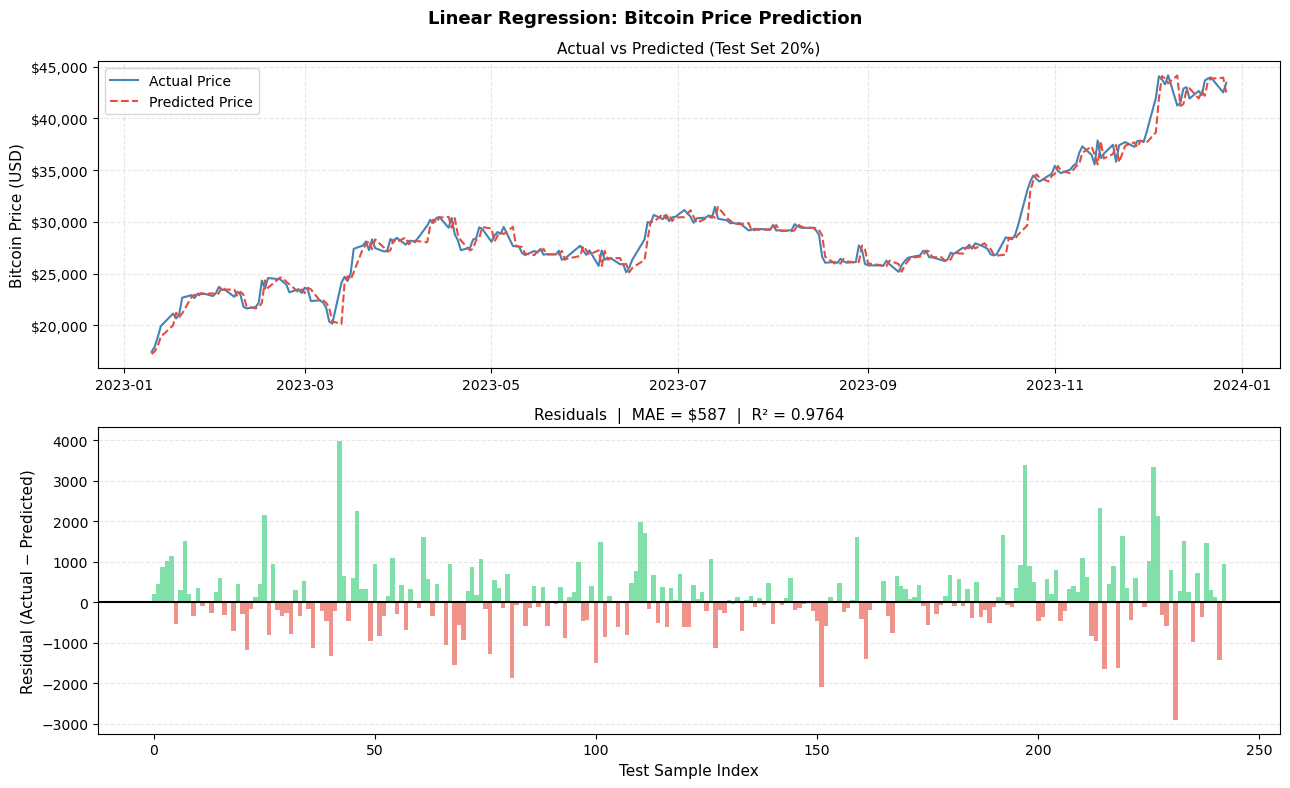

In [31]:
# ── Visualize: Actual vs Predicted  ─────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
fig.suptitle('Linear Regression: Bitcoin Price Prediction',
             fontsize=13, fontweight='bold')

test_dates = reg_df['Date'].iloc[split:].values

# ── Plot 1: Actual vs Predicted ───────────────────────────────────
ax1 = axes[0]
ax1.plot(test_dates, y_test_lr.values, label='Actual Price',    color='steelblue', lw=1.5)
ax1.plot(test_dates, y_pred_lr,        label='Predicted Price', color='#e74c3c',   lw=1.5, linestyle='--')
ax1.set_ylabel('Bitcoin Price (USD)', fontsize=11)
ax1.set_title('Actual vs Predicted (Test Set 20%)', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# ── Plot 2: Residuals (Error) ─────────────────────────────────────
ax2 = axes[1]
residuals = y_test_lr.values - y_pred_lr
ax2.bar(range(len(residuals)), residuals,
        color=['#e74c3c' if r < 0 else '#2ecc71' for r in residuals],
        alpha=0.6, width=1.0)
ax2.axhline(0, color='black', lw=1.5)
ax2.set_xlabel('Test Sample Index', fontsize=11)
ax2.set_ylabel('Residual (Actual − Predicted)', fontsize=11)
ax2.set_title(f'Residuals  |  MAE = ${mae:,.0f}  |  R² = {r2:.4f}', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

---
## คำถามที่ 4 — กลยุทธ์เลือกหุ้น Tech ตัวไหนคุ้มค่าที่สุด? (Sharpe Ratio)

**เป้าหมาย:** หาหุ้น Tech ที่มีความเสี่ยงต่ำแต่ผลตอบแทนสูงที่สุด โดยใช้ **Sharpe Ratio**

$$\text{Sharpe Ratio} = \frac{\text{Avg Daily Return}}{\text{Std Daily Return}} \times \sqrt{252}$$

| ค่า | ความหมาย |
|-----|---------|
| > 1.0 | ดีมาก — คุ้มค่าความเสี่ยง |
| 0.5–1.0 | พอรับได้ |
| < 0.5 | ไม่คุ้มความเสี่ยง |

In [32]:
# รายชื่อหุ้น Tech ที่จะวิเคราะห์
tech_stocks = ['Apple', 'Tesla', 'Microsoft', 'Google', 'Nvidia', 'Netflix', 'Amazon', 'Meta']

# ── คำนวณ Metrics แต่ละตัว ──────────────────────────────
results = []
for name in tech_stocks:
    prices    = stock_market_data[f'{name}_Price']
    daily_ret = prices.pct_change().dropna() * 100     # % เปลี่ยนแปลงรายวัน

    cum_ret   = (prices.iloc[-1] / prices.iloc[0] - 1) * 100  # ผลตอบแทนสะสม 5 ปี
    vol       = daily_ret.std()                                # Volatility = ความเสี่ยง
    sharpe    = daily_ret.mean() / vol * np.sqrt(252)          # Sharpe Ratio (Annualized)

    results.append({
        'Stock'           : name,
        'Cum_Return_%'    : round(cum_ret, 1),
        'Volatility_%day' : round(vol, 3),
        'Sharpe_Ratio'    : round(sharpe, 3)
    })

# เรียงจาก Sharpe สูงสุด → ต่ำสุด
strategy_df = (pd.DataFrame(results)
                 .sort_values('Sharpe_Ratio', ascending=False)
                 .reset_index(drop=True))
strategy_df.index += 1    # Rank เริ่มจาก 1
strategy_df

,Stock,Cum_Return_%,Volatility_%day,Sharpe_Ratio
1,Nvidia,1224.9,3.246,1.295
2,Apple,351.2,2.015,1.136
3,Tesla,1153.3,4.077,1.132
4,Microsoft,253.8,1.924,1.010
5,Google,146.0,2.023,0.741
6,Meta,111.4,2.766,0.577
7,Amazon,87.8,2.223,0.546
8,Netflix,40.0,2.915,0.390


In [33]:
# สร้างคอลัมน์ปี แล้วใช้ pivot_table สรุปผลตอบแทนรายปี
smd_pv = stock_market_data.copy()
smd_pv['Year'] = smd_pv['Date'].dt.year

annual_ret = {}
for name in tech_stocks:
    col = f'{name}_Price'
    # groupby Year แล้วหา % เปลี่ยนแปลง (ราคาสุดท้าย / ราคาแรกของปี - 1)
    annual_ret[name] = (smd_pv.groupby('Year')[col]
                               .apply(lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100)
                               .round(1))

annual_ret_df = pd.DataFrame(annual_ret)

# pivot_table: index=Year, columns=Stock, values=Annual Return %
pivot_annual = annual_ret_df.pivot_table(
    index=annual_ret_df.index,
    values=annual_ret_df.columns,
    aggfunc='first'          # ค่าที่คำนวณมาแล้ว ใช้ first
)
print("Annual Return (%) แต่ละปี:")
pivot_annual.round(1)

Annual Return (%) แต่ละปี:


,Amazon,Apple,Google,Meta,Microsoft,Netflix,Nvidia,Tesla
Year,,,,,,,,
2019,13.1,71.5,17.3,21.3,49.1,-7.9,57.7,33.7
2020,71.6,76.7,28.1,30.2,38.5,64.0,117.7,720.2
2021,4.6,37.2,67.8,25.1,54.5,15.2,124.3,44.8
2022,-50.7,-28.6,-39.1,-64.5,-28.4,-50.6,-51.5,-69.2
2023,78.7,54.4,57.5,186.9,56.1,66.7,245.2,141.9


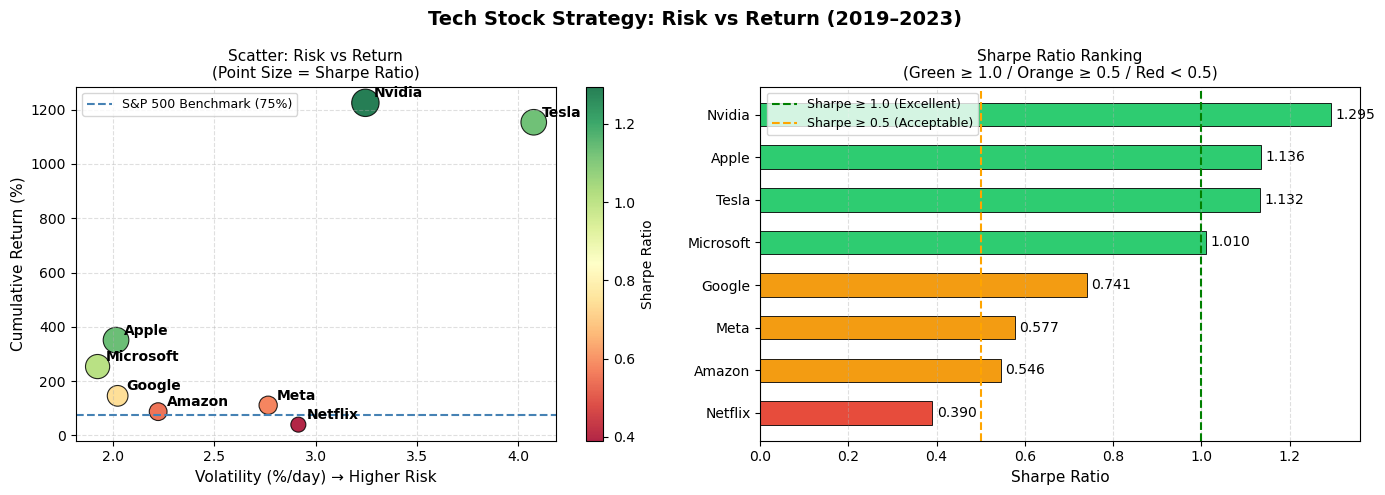

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tech Stock Strategy: Risk vs Return (2019–2023)', fontsize=14, fontweight='bold')

# ── Plot 1: Scatter — Volatility vs Cumulative Return ────────────────
ax1 = axes[0]
sc = ax1.scatter(
    strategy_df['Volatility_%day'],
    strategy_df['Cum_Return_%'],
    s=strategy_df['Sharpe_Ratio'] * 300,   # point size proportional to Sharpe Ratio
    c=strategy_df['Sharpe_Ratio'],
    cmap='RdYlGn', alpha=0.85, edgecolors='black', linewidths=0.8
)

# Label each point
for _, row in strategy_df.iterrows():
    ax1.annotate(row['Stock'],
                 xy=(row['Volatility_%day'], row['Cum_Return_%']),
                 xytext=(6, 4), textcoords='offset points',
                 fontsize=10, fontweight='bold')

plt.colorbar(sc, ax=ax1, label='Sharpe Ratio')

# S&P 500 Benchmark line
sp_cum = (stock_market_data['S&P_500_Price'].iloc[-1] /
          stock_market_data['S&P_500_Price'].iloc[0] - 1) * 100
ax1.axhline(sp_cum, color='steelblue', linestyle='--', lw=1.5,
            label=f'S&P 500 Benchmark ({sp_cum:.0f}%)')

ax1.set_xlabel('Volatility (%/day) → Higher Risk', fontsize=11)
ax1.set_ylabel('Cumulative Return (%)', fontsize=11)
ax1.set_title('Scatter: Risk vs Return\n(Point Size = Sharpe Ratio)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# ── Plot 2: Horizontal Bar — Sharpe Ratio Ranking ────────────────────
ax2 = axes[1]

bar_colors = ['#2ecc71' if s >= 1.0 else '#f39c12' if s >= 0.5 else '#e74c3c'
               for s in strategy_df['Sharpe_Ratio']]

bars = ax2.barh(strategy_df['Stock'][::-1],        # reversed so rank 1 appears at the top
                strategy_df['Sharpe_Ratio'][::-1],
                color=bar_colors[::-1], edgecolor='black', linewidth=0.6, height=0.55)

ax2.axvline(1.0, color='green',  linestyle='--', lw=1.5, label='Sharpe ≥ 1.0 (Excellent)')
ax2.axvline(0.5, color='orange', linestyle='--', lw=1.5, label='Sharpe ≥ 0.5 (Acceptable)')

for bar, val in zip(bars, strategy_df['Sharpe_Ratio'][::-1]):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

ax2.set_xlabel('Sharpe Ratio', fontsize=11)
ax2.set_title('Sharpe Ratio Ranking\n(Green ≥ 1.0 / Orange ≥ 0.5 / Red < 0.5)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

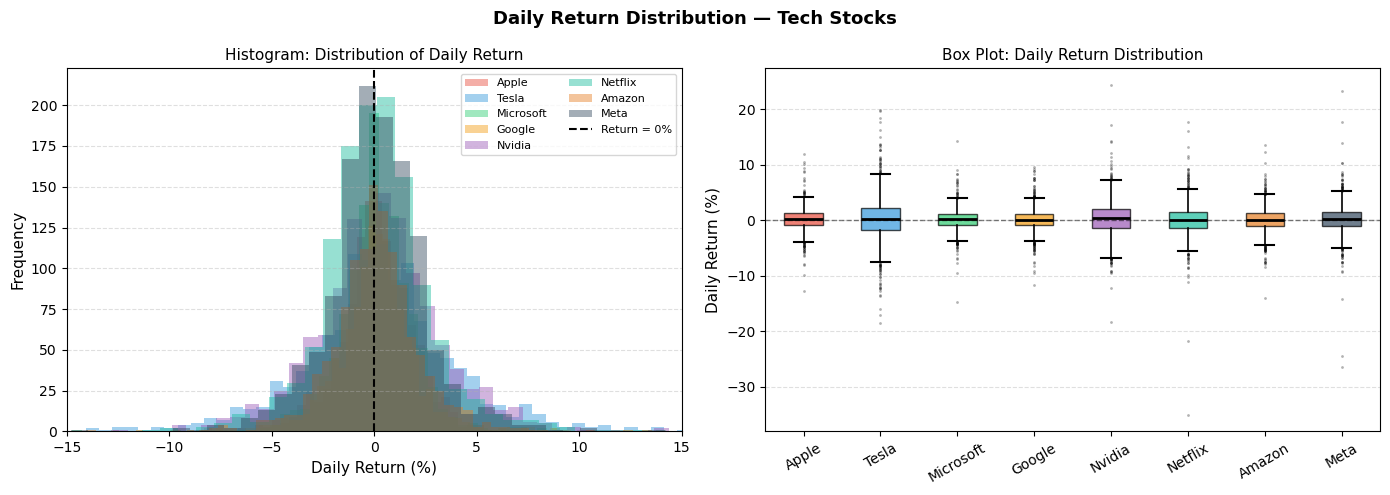

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Daily Return Distribution — Tech Stocks', fontsize=13, fontweight='bold')

ax1 = axes[0]
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e']
for (name, color) in zip(tech_stocks, colors):
    ret = stock_market_data[f'{name}_Price'].pct_change().dropna() * 100
    ax1.hist(ret, bins=60, alpha=0.45, color=color, label=name, edgecolor='none')

ax1.axvline(0, color='black', linestyle='--', lw=1.5, label='Return = 0%')
ax1.set_xlabel('Daily Return (%)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Histogram: Distribution of Daily Return', fontsize=11)
ax1.set_xlim(-15, 15)
ax1.legend(fontsize=8, ncol=2)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

#  เปรียบ Volatility 
ax2 = axes[1]
daily_returns = [stock_market_data[f'{t}_Price'].pct_change().dropna() * 100
                 for t in tech_stocks]

bp = ax2.boxplot(daily_returns, labels=tech_stocks, patch_artist=True,
                  medianprops=dict(color='black', lw=2),
                  whiskerprops=dict(lw=1.2), capprops=dict(lw=1.5),
                  flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax2.axhline(0, color='black', linestyle='--', lw=1, alpha=0.5)
ax2.set_ylabel('Daily Return (%)', fontsize=11)
ax2.set_title('Box Plot: Daily Return Distribution', fontsize=11)
ax2.tick_params(axis='x', rotation=30)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## คำถามที่ 5 — Weekly Dashboard: ผลตอบแทนรายสัปดาห์ของหุ้น Tech เป็นอย่างไร?

**เป้าหมาย:** ติดตามผลตอบแทน % รายสัปดาห์ เปรียบเทียบหุ้นหลัก vs S&P 500

In [36]:
# ── Resample ราคาเป็นรายสัปดาห์ ────────────────────────
df_indexed = stock_market_data.set_index('Date')

weekly_price_cols = [f'{t}_Price' for t in tech_stocks] + ['S&P_500_Price']

# resample('W').last() = ราคาปิดของวันสุดท้ายในแต่ละสัปดาห์
weekly_prices = df_indexed[weekly_price_cols].resample('W').last()

# คำนวณ Weekly Return (%)
weekly_ret = weekly_prices.pct_change() * 100
weekly_ret.columns = tech_stocks + ['S&P 500']    # ชื่อสั้นลง

# แสดง 10 สัปดาห์ล่าสุด
weekly_last10 = weekly_ret.tail(10)
print("Weekly Return (%) — 10 สัปดาห์ล่าสุด:")
weekly_last10.round(2)

Weekly Return (%) — 10 สัปดาห์ล่าสุด:


,Apple,Tesla,Microsoft,Google,Nvidia,Netflix,Amazon,Meta,S&P 500
Date,,,,,,,,,
2023-10-29,-2.70,-2.21,0.96,-9.90,-2.14,-0.77,2.05,-3.86,-2.53
2023-11-05,5.01,6.11,6.97,5.67,11.12,8.67,8.50,6.02,5.85
2023-11-12,5.52,-2.41,4.78,2.70,7.40,3.44,3.58,4.50,1.31
2023-11-19,1.77,9.15,0.05,2.05,1.99,4.17,1.13,1.91,2.24
2023-11-26,0.15,0.49,2.05,1.02,-3.09,2.93,1.07,0.95,1.00
2023-12-03,0.67,1.44,-0.77,-3.53,-2.12,-2.88,0.20,-3.96,0.77
2023-12-10,2.34,2.10,-0.07,2.37,1.58,-2.57,0.27,2.44,0.21
2023-12-17,0.95,3.96,-0.94,-1.77,2.91,4.03,1.73,0.65,2.49
2023-12-24,-2.01,-0.38,1.04,6.70,-0.12,3.11,2.30,5.51,0.75


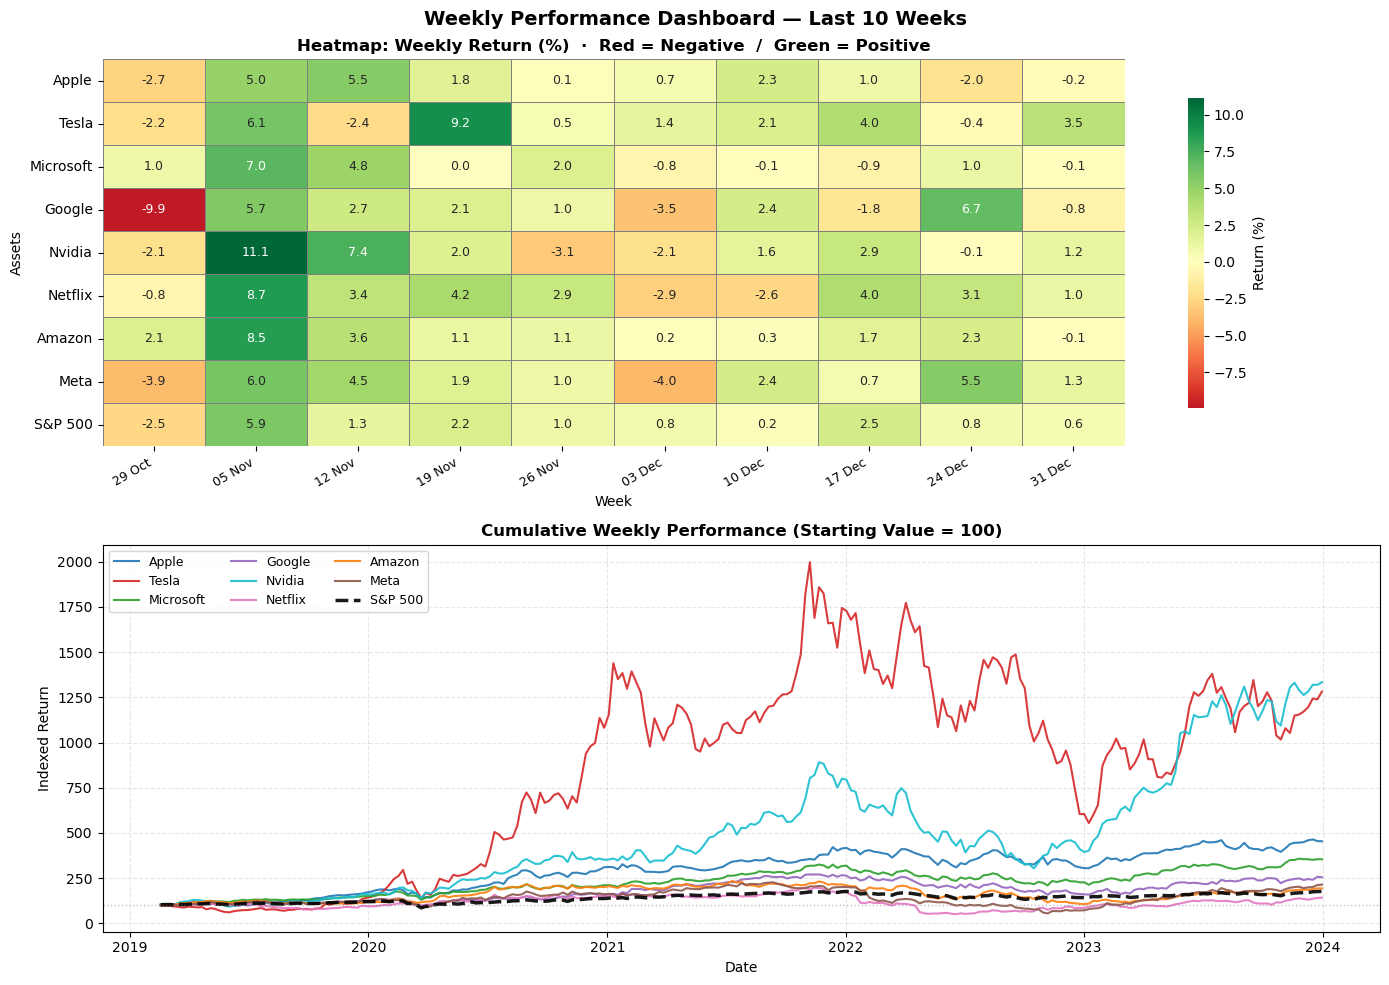

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Weekly Performance Dashboard — Last 10 Weeks',
             fontsize=14, fontweight='bold')

# ── Plot 1: Seaborn Heatmap ──────────────────────────────
ax1 = axes[0]
sns.heatmap(
    weekly_last10.T,           # Transpose: X-axis = Weeks, Y-axis = Stocks
    ax=ax1,
    annot=True,                # Show numbers inside each cell
    fmt='.1f',                 # 1 decimal place
    cmap='RdYlGn',             # Red = Negative, Green = Positive
    center=0,                  # 0% = Yellow (center)
    linewidths=0.5, linecolor='gray',
    cbar_kws={'label': 'Return (%)', 'shrink': 0.8},
    annot_kws={'size': 9}
)

ax1.set_title('Heatmap: Weekly Return (%)  ·  Red = Negative  /  Green = Positive',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Week', fontsize=10)
ax1.set_ylabel('Assets', fontsize=10)

ax1.set_xticklabels(
    [d.strftime('%d %b') for d in weekly_last10.index],
    rotation=30, ha='right', fontsize=9
)

# ── Plot 2: Cumulative Performance Line Chart ────────────
ax2 = axes[1]

# Indexed return starting at 100 for easier comparison
cum_weekly = (1 + weekly_ret / 100).cumprod() * 100

stock_colors = {
    'Apple': '#1f77b4',      # dark blue
    'Tesla': '#d62728',      # red
    'Microsoft': '#2ca02c',  # green
    'Google': '#9467bd',     # purple
    'Nvidia': '#17becf',     # cyan
    'Netflix': '#e377c2',    # pink
    'Amazon': '#ff7f0e',     # orange
    'Meta': '#8c564b',       # brown
    'S&P 500': '#000000'     # black
}

for col, color in stock_colors.items():
    is_sp = (col == 'S&P 500')
    ax2.plot(cum_weekly.index, cum_weekly[col],
             label=col, color=color,
             linewidth=2.5 if is_sp else 1.5,
             linestyle='--' if is_sp else '-',
             alpha=0.9)

ax2.axhline(100, color='gray', linestyle=':', lw=1, alpha=0.5)

ax2.set_title('Cumulative Weekly Performance (Starting Value = 100)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Date', fontsize=10)
ax2.set_ylabel('Indexed Return', fontsize=10)

ax2.legend(ncol=3, fontsize=9, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

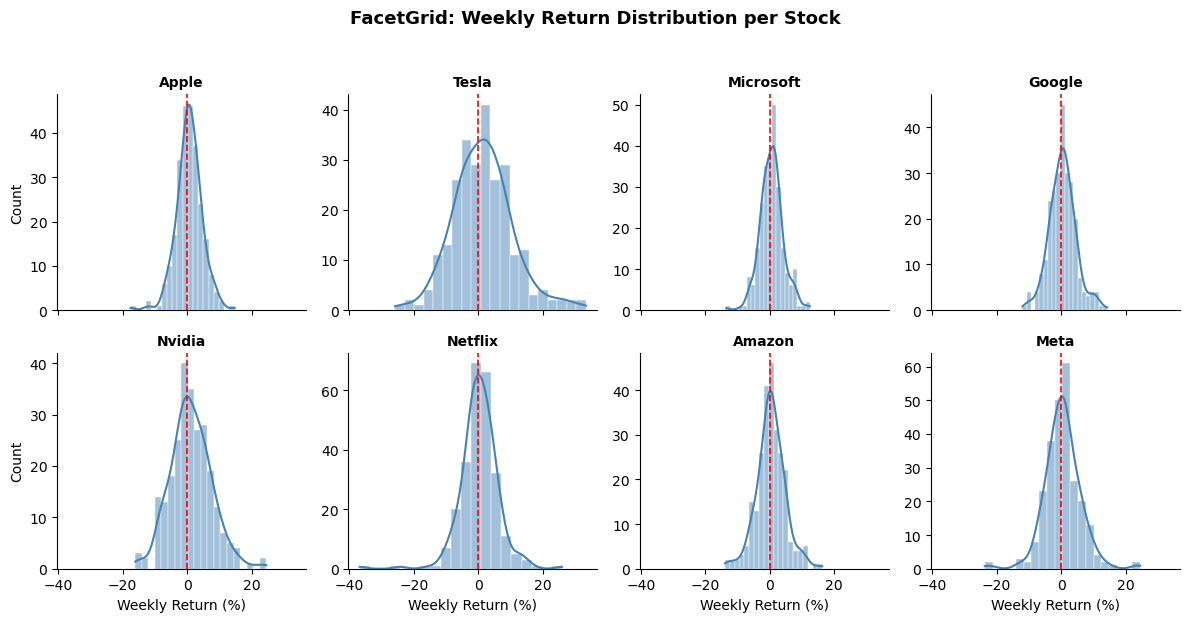

In [38]:
# แปลง weekly_ret เป็น long format เพื่อใช้กับ FacetGrid
weekly_long = weekly_ret[tech_stocks].stack().reset_index()
weekly_long.columns = ['Date', 'Stock', 'Weekly_Return_%']

# FacetGrid: แต่ละ col = หุ้น 1 ตัว แสดง Histogram ของ Weekly Return
g = sns.FacetGrid(data=weekly_long, col='Stock',
                  col_wrap=4,          # 4 กราฟต่อแถว
                  height=3, aspect=1,
                  sharey=False)

g.map(sns.histplot, 'Weekly_Return_%',
      bins=20, kde=True,              # kde=True เพิ่มเส้นโค้งความน่าจะเป็น
      color='steelblue', edgecolor='white', lw=0.3)

g.map(plt.axvline, x=0, color='red', linestyle='--', lw=1.2)
g.set_titles(col_template='{col_name}', fontsize=11, fontweight='bold')
g.set_axis_labels('Weekly Return (%)', 'Count')
g.figure.suptitle('FacetGrid: Weekly Return Distribution per Stock',
                   y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## คำถามที่ 6 — Buy Advisor: ควรซื้อหุ้นตัวไหน ณ ตอนนี้?

**เป้าหมาย:** วิเคราะห์ว่าควรซื้อหุ้นตัวไหน ราคาดีไหม และความเสี่ยงอยู่ระดับใด

**ตัวชี้วัดที่ใช้:**

| ตัวชี้วัด | ความหมาย | เกณฑ์ตัดสิน |
|---------|---------|-----------|
| **RSI (14 วัน)** | Momentum — ซื้อมากหรือขายมากเกินไป? | < 30 = Oversold 🟢, > 70 = Overbought 🔴 |
| **52-Week Range** | ราคาปัจจุบันอยู่ตรงไหนใน 1 ปี | ใกล้ Low = โอกาส, ใกล้ High = ระวัง |
| **Risk Score** | ความผันผวนรายวัน × 10 | < 25 = ต่ำ, 25–40 = กลาง, > 40 = สูง |

> ⚠️ **ไม่ใช่คำแนะนำการลงทุน — ใช้เพื่อการศึกษาเท่านั้น**

In [39]:
# ── Function: คำนวณ RSI (14 วัน) ───────────────────────
def compute_rsi(price_series, period=14):
    delta = price_series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()   # เฉลี่ยวันที่ขึ้น
    loss  = (-delta.clip(upper=0)).rolling(period).mean() # เฉลี่ยวันที่ลง
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

# ── Function: แปล RSI + % from High → Signal ────────────
def get_signal(rsi_val, pct_from_high):
    if   rsi_val < 30:           return 'BUY',  '🟢 Oversold — ราคาถูก เหมาะสะสม'
    elif rsi_val > 70:           return 'WAIT', '🔴 Overbought — ราคาแพง ควรรอ Pullback'
    elif pct_from_high < -20:    return 'BUY',  '🟡 ต่ำกว่า 52w High มาก — อาจเป็นโอกาส'
    else:                        return 'HOLD', '🟡 Neutral — ยังไม่มีสัญญาณชัดเจน'

# ── คำนวณ Metrics ทุกตัว ─────────────────────────────────
advisor_stocks  = ['Apple', 'Tesla', 'Nvidia', 'Microsoft', 'Google']
advisor_results = []

for name in advisor_stocks:
    prices = stock_market_data[f'{name}_Price']

    rsi_val       = round(compute_rsi(prices).iloc[-1], 1)
    current_price = prices.iloc[-1]
    high_52w      = prices.tail(252).max()               # สูงสุดใน ~1 ปี (252 วันทำการ)
    low_52w       = prices.tail(252).min()               # ต่ำสุดใน ~1 ปี
    pct_from_high = (current_price - high_52w) / high_52w * 100
    pct_from_low  = (current_price - low_52w)  / low_52w  * 100

    # Risk Score: Volatility รายวัน (%) × 10  →  scale 0–100
    daily_vol  = prices.pct_change().dropna().std() * 100
    risk_score = round(min(100, daily_vol * 10), 1)

    signal, desc = get_signal(rsi_val, pct_from_high)

    advisor_results.append({
        'Stock'       : name,
        'Price'       : round(current_price, 2),
        '52w_High'    : round(high_52w, 2),
        '52w_Low'     : round(low_52w, 2),
        'From_High_%' : round(pct_from_high, 1),
        'From_Low_%'  : round(pct_from_low, 1),
        'RSI_14'      : rsi_val,
        'Daily_Vol_%' : round(daily_vol, 3),
        'Risk_Score'  : risk_score,
        'Signal'      : signal,
        'Description' : desc
    })

advisor_df = pd.DataFrame(advisor_results)
advisor_df[['Stock','Price','RSI_14','From_High_%','Risk_Score','Signal','Description']]

,Stock,Price,RSI_14,From_High_%,Risk_Score,Signal,Description
0,Apple,193.15,52.3,-2.5,20.1,HOLD,🟡 Neutral — ยังไม่มีสัญญาณชัดเจน
1,Tesla,261.44,67.6,-10.9,40.8,HOLD,🟡 Neutral — ยังไม่มีสัญญาณชัดเจน
2,Nvidia,494.17,69.7,-2.0,32.5,HOLD,🟡 Neutral — ยังไม่มีสัญญาณชัดเจน
3,Microsoft,374.07,57.6,-2.3,19.2,HOLD,🟡 Neutral — ยังไม่มีสัญญาณชัดเจน
4,Google,140.37,72.8,-0.8,20.2,WAIT,🔴 Overbought — ราคาแพง ควรรอ Pullback


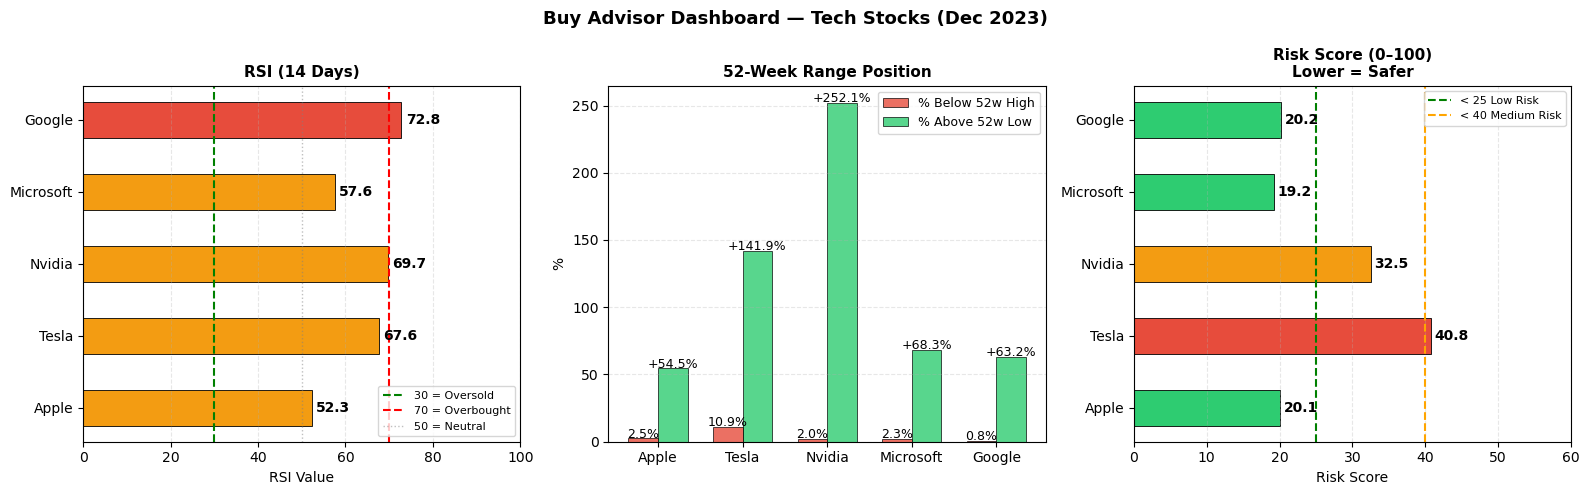

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Buy Advisor Dashboard — Tech Stocks (Dec 2023)', fontsize=13, fontweight='bold')

names = advisor_df['Stock'].tolist()

# ── Plot 1: RSI Gauge ────────────────────────────────────
ax1 = axes[0]
rsi_colors = ['#2ecc71' if r < 30 else '#e74c3c' if r > 70 else '#f39c12'
               for r in advisor_df['RSI_14']]

bars1 = ax1.barh(names, advisor_df['RSI_14'],
                 color=rsi_colors, edgecolor='black', lw=0.6, height=0.5)

ax1.axvline(30, color='green', linestyle='--', lw=1.5, label='30 = Oversold')
ax1.axvline(70, color='red',   linestyle='--', lw=1.5, label='70 = Overbought')
ax1.axvline(50, color='gray',  linestyle=':',  lw=1,   alpha=0.5, label='50 = Neutral')

ax1.set_xlim(0, 100)
ax1.set_title('RSI (14 Days)', fontsize=11, fontweight='bold')
ax1.set_xlabel('RSI Value')

ax1.legend(fontsize=8)
ax1.grid(axis='x', linestyle='--', alpha=0.3)

for bar, val in zip(bars1, advisor_df['RSI_14']):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=10, fontweight='bold')

# ── Plot 2: 52-Week Range Position ──────────────────────
ax2 = axes[1]

x, w = np.arange(len(names)), 0.35

b1 = ax2.bar(x - w/2, advisor_df['From_High_%'].abs(), w,
              label='% Below 52w High', color='#e74c3c', alpha=0.8,
              edgecolor='black', lw=0.6)

b2 = ax2.bar(x + w/2, advisor_df['From_Low_%'], w,
              label='% Above 52w Low',  color='#2ecc71', alpha=0.8,
              edgecolor='black', lw=0.6)

ax2.set_xticks(x)
ax2.set_xticklabels(names, fontsize=10)

ax2.set_title('52-Week Range Position', fontsize=11, fontweight='bold')
ax2.set_ylabel('%')

ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

for bar in b1:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9)

for bar in b2:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'+{bar.get_height():.1f}%', ha='center', fontsize=9)

# ── Plot 3: Risk Score ───────────────────────────────────
ax3 = axes[2]

risk_colors = ['#2ecc71' if r < 25 else '#f39c12' if r < 40 else '#e74c3c'
                for r in advisor_df['Risk_Score']]

bars3 = ax3.barh(names, advisor_df['Risk_Score'],
                  color=risk_colors, edgecolor='black', lw=0.6, height=0.5)

ax3.axvline(25, color='green',  linestyle='--', lw=1.5, label='< 25 Low Risk')
ax3.axvline(40, color='orange', linestyle='--', lw=1.5, label='< 40 Medium Risk')

ax3.set_xlim(0, 60)
ax3.set_title('Risk Score (0–100)\nLower = Safer', fontsize=11, fontweight='bold')
ax3.set_xlabel('Risk Score')

ax3.legend(fontsize=8)
ax3.grid(axis='x', linestyle='--', alpha=0.3)

for bar, val in zip(bars3, advisor_df['Risk_Score']):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()